## Strategy Backtest I

- Backtest of a trading strategy to buy one share per minute, goal is to achieve lower fill price compared with arrival ask price. Rolling window is constructed to train a logistic regression on recent ticks to predict the probability the ask price rises.
- If predict future ask price rise, prefer execution now; if predict future ask price down, prefer waiting.

Sections:
1. **Raw Data Loading** -- load tick data, truncate order book depth, carve out a holdout period.
2. **Feature Engineering** -- build direction factors + label, assemble rolling train/test windows.
3. **Run Trading Simulation** -- walk forward window by window: train, predict, generate signal, simulate fills.
4. **Trade Result Evaluation** -- summary metrics and diagnostic plots for the backtest.
5. **Holdout Evaluation** -- results reported on holdout data, which is never used during model development

Results reported using NVDA MBP data on 2026-07-01.

### Raw Data Loading

Load raw MBP-10 ticks, trim the opening/closing minutes, and truncate to `data_depth` book levels. Then split off a holdout period (`data_holdout`) which is reserved for out-of-sample validation of any hyperparameters tuned on `data_train`.

In [150]:
### Data Loading
from execution_timing.data_loading import read_raw_data, truncate_depth, holdout_split
from execution_timing.config import FACTOR_HYPERPARAMETERS_DIRECTION, LABEL_HYPERPARAMETERS
from execution_timing.feature_engineering import load_factors_and_labels
from execution_timing.rolling_window_generator import RollingWindowGenerator, Window

data_mbp10 = read_raw_data('data_raw/nvda_mbp-10_2026-07-01.parquet', trim_open_and_close=True)
data_depth = 3
data = truncate_depth(data_mbp10, data_depth)
data_train, data_holdout = holdout_split(data, holdout_mins=120, purge_ticks=0)
print(f"Train data shape: {data_train.shape}")
print(f"Holdout data shape: {data_holdout.shape}")

Train data shape: (1797483, 12)
Holdout data shape: (621973, 12)


### Feature Engineering

Build the direction factors (`FACTOR_HYPERPARAMETERS_DIRECTION`) and the `ask_return_direction` label on `data_train`, and split into rolling train/test windows (`RollingWindowGenerator`) for walk-forward backtesting.

In [151]:
factors, labels = load_factors_and_labels(
    data=data_train,
    data_depth=data_depth,
    factor_hyperparameters=FACTOR_HYPERPARAMETERS_DIRECTION,
    label_hyperparameters=LABEL_HYPERPARAMETERS,
    dropna=True)

X = factors
y = labels['ask_return_direction']
rolling_window_generator = RollingWindowGenerator(X=X,
                                                  y=y,
                                                  train_window_size_mins=25,
                                                  test_window_size_mins=5,
                                                  step_size_mins=5,
                                                  purge_secs=1)
windows = list(iter(rolling_window_generator))
print(f"Windows count: {len(windows)}")
print(f"Windows start time: {windows[0].train_start}")
print(f"Windows end time: {windows[-1].test_end}")

Dropped 600 rows with NaN values
Windows count: 37
Windows start time: 2026-07-01 10:00:00-04:00
Windows end time: 2026-07-01 13:30:00-04:00


### Run Trading Simulation

- `PredictionModel` -- wraps `LogisticRegression` which is used to predict future price direction
- `StrategyDirection` -- converts model prediction into 0/1 trading signal
- `TradingSimulator` -- turns trading signal into fills against raw ask/bid ticks.

`run_simulation` walks forward window by window, retraining, predicting, generating the signal, and simulating fills, returning the per-minute trade results (`trading_result`) and each window's fitted factor coefficients (`model_coeff`).

In [152]:
from execution_timing.prediction_model import PredictionModel
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from execution_timing.trading_strategy import StrategyDirection
from execution_timing.trading_simulator import TradingSimulator, run_simulation


dir_model = PredictionModel(
    model=LogisticRegression(l1_ratio=0, # penalty = l1_ratio * L1 + (1 − l1_ratio) * L2; l1_ratio=0 -> Ridge
                           C=0.01, # C=1/alpha where alpha is the coefficient for penalty term; bigger alpha mode penalty
                           max_iter=10000,),
    scaler=StandardScaler(),
)

strategy = StrategyDirection(dir_pred_model=dir_model,
                             dir_threshold=0.56,
                             sig_resample_freq=None)
trading_simulator = TradingSimulator(raw_price=data_train[['ask_px_00', 'bid_px_00']],
                             execution_lag_ticks=0)


In [153]:
trading_result, model_coeff = run_simulation(strategy=strategy,
                            trading_simulator=trading_simulator,
                            windows=windows)

In [154]:
display(trading_result)

,#window,execution_time,execution_second,fill_price,arrival_ask,departure_ask,mean_ask,max_ask,min_ask,arrival_bid,departure_bid,arrival_spread,departure_spread,pnl,pnl_pct_spread
2026-07-01 10:25:00-04:00,0,2026-07-01 10:25:13.087319019-04:00,13.087319,196.20,196.10,196.16,196.177401,196.26,196.08,196.08,196.14,0.02,0.02,-0.10,-5.0
2026-07-01 10:26:00-04:00,0,2026-07-01 10:26:03.661727404-04:00,3.661727,196.21,196.16,196.44,196.458206,196.58,196.16,196.14,196.42,0.02,0.02,-0.05,-2.5
2026-07-01 10:27:00-04:00,0,2026-07-01 10:27:07.599672451-04:00,7.599672,196.40,196.44,196.45,196.419922,196.49,196.36,196.42,196.43,0.02,0.02,0.04,2.0
2026-07-01 10:28:00-04:00,0,2026-07-01 10:28:04.550467847-04:00,4.550468,196.41,196.45,196.29,196.295532,196.49,196.19,196.43,196.27,0.02,0.02,0.04,2.0
2026-07-01 10:29:00-04:00,0,2026-07-01 10:29:00.115625722-04:00,0.115626,196.31,196.29,196.22,196.221956,196.31,196.12,196.27,196.19,0.02,0.03,-0.02,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-07-01 13:25:00-04:00,36,2026-07-01 13:25:00.605778448-04:00,0.605778,198.20,198.17,198.37,198.371883,198.49,198.17,198.16,198.36,0.01,0.01,-0.03,-3.0
2026-07-01 13:26:00-04:00,36,2026-07-01 13:26:03.413148119-04:00,3.413148,198.35,198.37,198.32,198.313893,198.43,198.21,198.36,198.31,0.01,0.01,0.02,2.0
2026-07-01 13:27:00-04:00,36,2026-07-01 13:27:01.103739439-04:00,1.103739,198.34,198.32,198.21,198.334385,198.45,198.15,198.31,198.19,0.01,0.02,-0.02,-2.0
2026-07-01 13:28:00-04:00,36,2026-07-01 13:28:01.517775317-04:00,1.517775,198.18,198.21,198.20,198.148157,198.25,198.07,198.19,198.19,0.02,0.01,0.03,1.5


In [155]:
display(model_coeff)

,window_0,window_1,window_2,window_3,window_4,window_5,window_6,window_7,window_8,window_9,...,window_27,window_28,window_29,window_30,window_31,window_32,window_33,window_34,window_35,window_36
obi_weighted,0.110284,0.107938,0.115542,0.128563,0.143018,0.127663,0.106629,0.106242,0.097488,0.084830,...,0.174413,0.180547,0.184102,0.180374,0.131271,0.091599,0.083571,0.121760,0.095370,0.124938
spread_deviation,-0.104297,-0.115267,-0.111079,-0.144012,-0.110565,-0.104470,-0.122477,-0.128692,-0.135646,-0.126852,...,-0.185344,-0.192036,-0.189505,-0.162318,-0.159681,-0.093900,-0.108531,-0.087031,-0.095878,-0.102961
ask_px_momentum,0.020147,0.038312,0.053449,0.083567,0.048909,0.037103,0.047994,0.052871,0.054551,0.030934,...,0.050464,0.065634,0.053161,0.046346,0.053605,0.025466,0.015362,0.047517,0.052053,0.042492
bid_px_momentum,0.077438,0.068837,0.084862,0.051141,0.074245,0.096392,0.088997,0.092660,0.055159,0.064211,...,-0.039191,-0.053602,-0.053824,0.015213,0.018811,0.078381,0.098008,0.146391,0.136519,0.132900
vwap_mid_deviation_ask,-0.025778,-0.009311,-0.001883,0.002743,0.008843,0.021002,0.011225,-0.001381,-0.014926,-0.035440,...,-0.116576,-0.102217,-0.134726,-0.072209,-0.058711,-0.068520,-0.038070,0.006292,-0.018641,-0.034250


### Trade Result Evaluation

Summary metrics (cumulative/mean pnl, win rate, Sharpe ratio, trigger rate) plus diagnostic plots.

In [156]:
from execution_timing.visualization import (plot_cumulative_pnl,
                                            plot_execution_second_distribution,
                                            plot_pnl_histogram,
                                            plot_price_path,
                                            plot_coefficient_distribution,
                                            plot_price_and_pnl)
from execution_timing.trading_simulator import summarize_results, baseline_comparison

stats = summarize_results(trading_result)
display(stats)

,cumulative_pnl,win_rate,sharpe_ratio,mean_pnl,mean_pnl_pct_spread,trigger_rate,mean_arrival_spread
stats,1.53,0.427027,0.138949,0.00827,0.400901,0.994595,0.01827


In [157]:
baseline_stats = baseline_comparison(trading_result)
display(baseline_stats)

,mean_pnl_per_share
buy_immediately,0.000000
random_tick,-0.005941
always_wait,-0.011405
model_timed,0.008270
perfect_foresight,0.109081


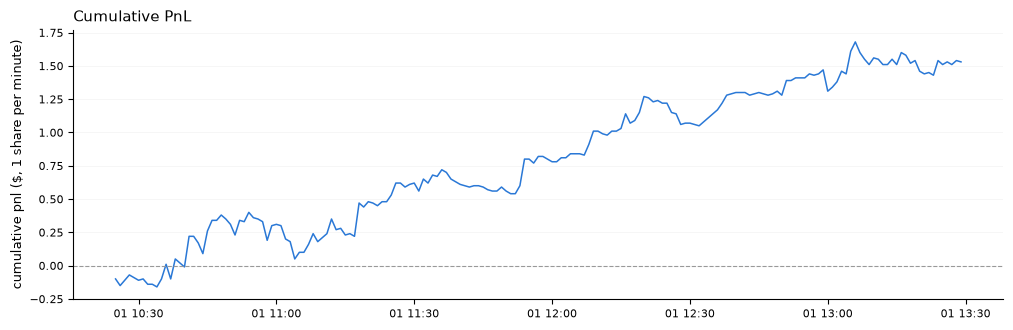

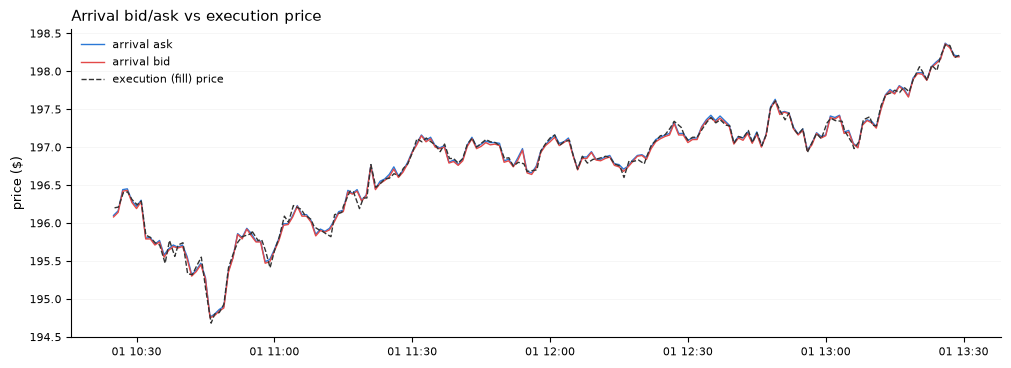

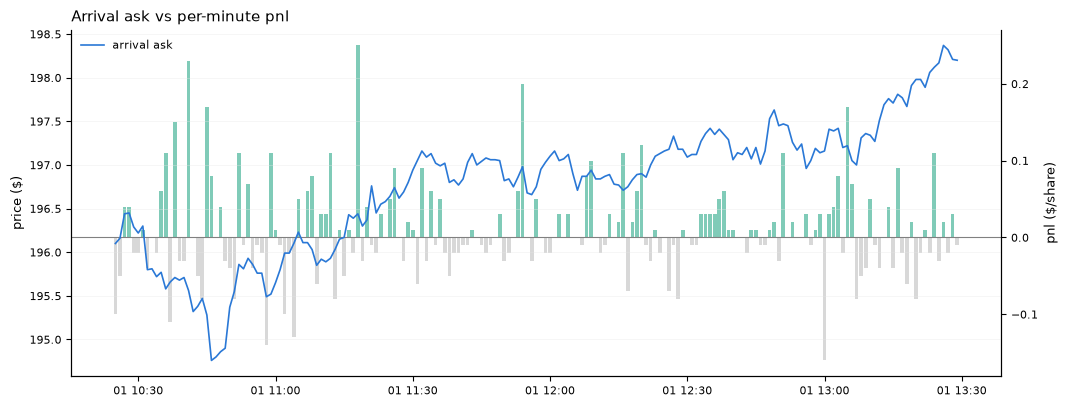

In [158]:
# cumulative pnl over the backtest
plot_cumulative_pnl(trading_result['pnl'].cumsum())

# arrival/departure bid-ask vs execution (fill) price, per minute
plot_price_path(trading_result)

# arrival ask overlaid with per-minute pnl on the same time axis
plot_price_and_pnl(trading_result)

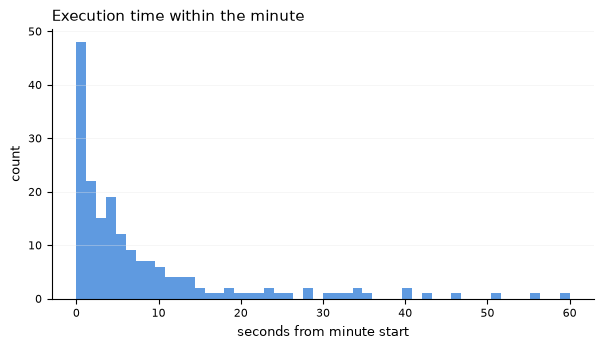

In [159]:
# when does execution happen in each minute
plot_execution_second_distribution(trading_result['execution_second'], bins=50)

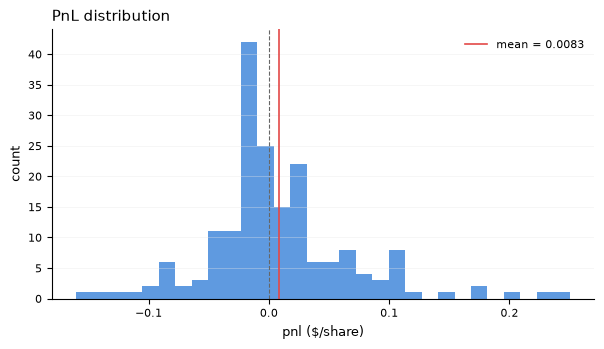

In [160]:
# per-minute pnl distribution
plot_pnl_histogram(trading_result['pnl'], bins=30)

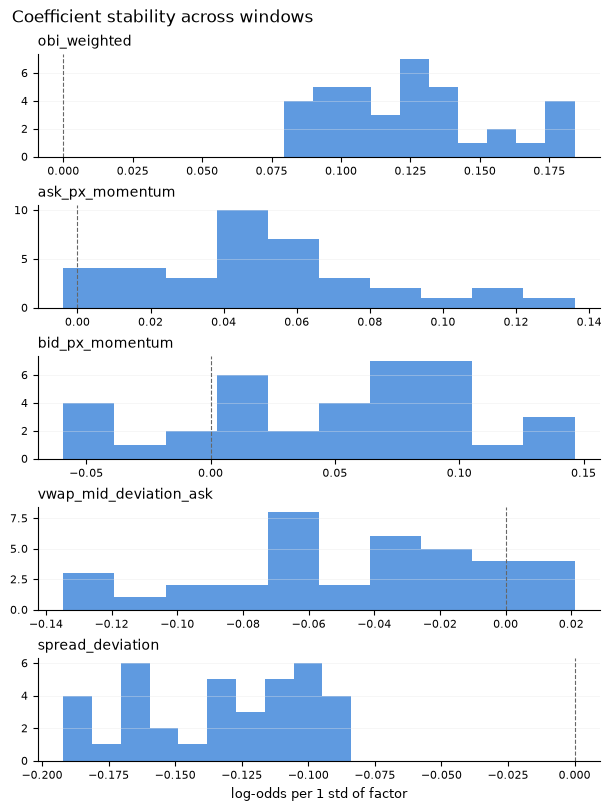

In [161]:
# per-factor coefficient stability across rolling windows; expect signs to be stable
plot_coefficient_distribution(model_coeff, bins=10)

### Holdout Evaluation
- True out-of-sample data which was never used before.
- Same pipeline (feature engineering -> rolling windows -> `run_simulation` -> `summarize_results` + plots) as above, run on `data_holdout` instead of `data_train`.

Dropped 600 rows with NaN values
Windows count: 19
Windows start time: 2026-07-01 13:30:00-04:00
Windows end time: 2026-07-01 15:30:00-04:00


,cumulative_pnl,win_rate,sharpe_ratio,mean_pnl,mean_pnl_pct_spread,trigger_rate,mean_arrival_spread
stats,0.49,0.378947,0.105856,0.005158,0.322807,0.842105,0.016316


,mean_pnl_per_share
buy_immediately,0.000000
random_tick,-0.004406
always_wait,-0.006737
model_timed,0.005158
perfect_foresight,0.086211


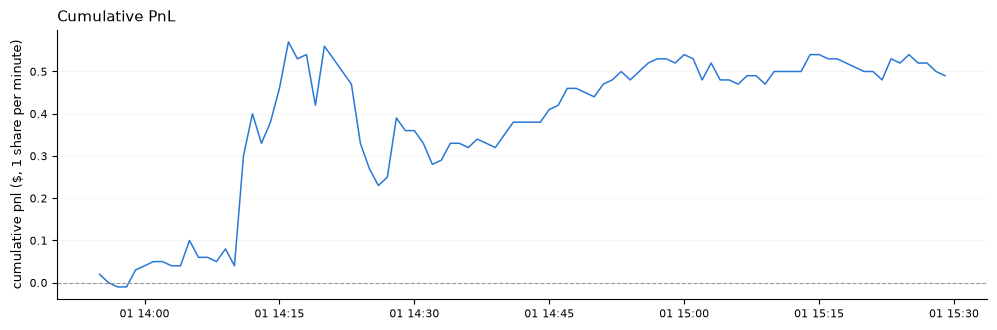

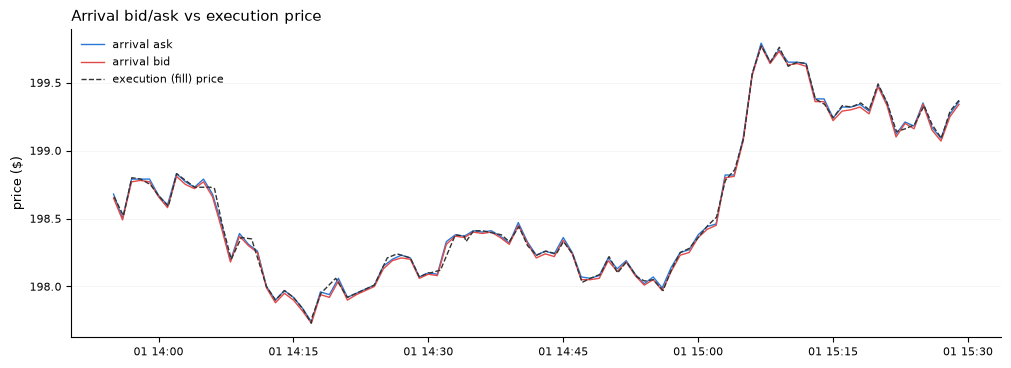

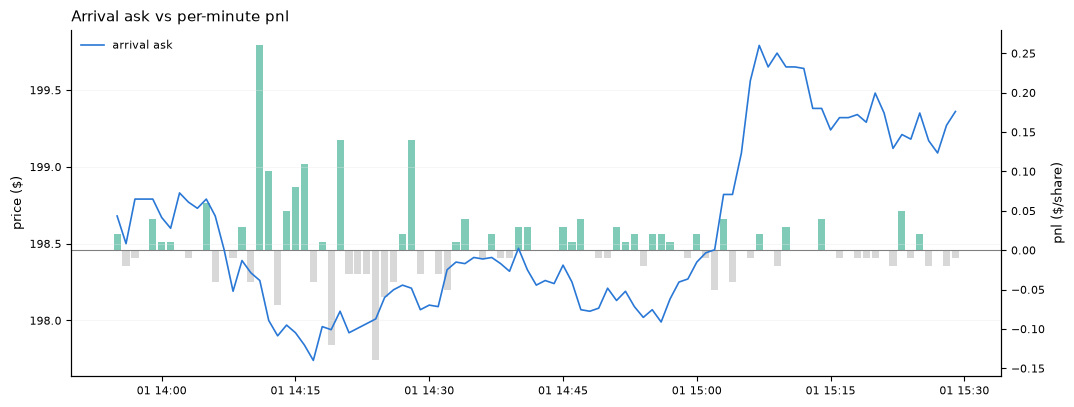

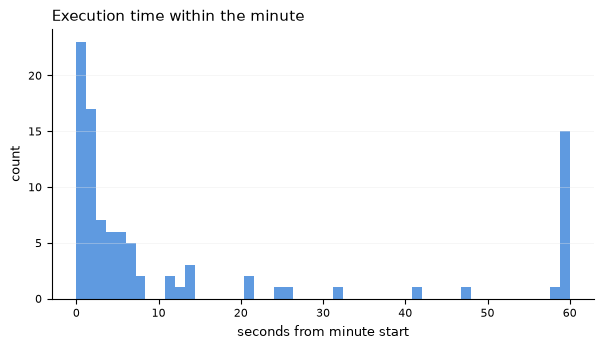

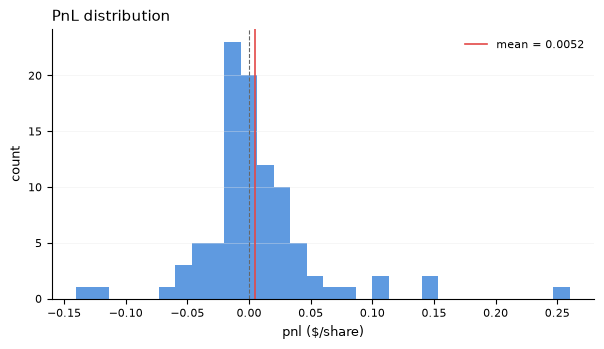

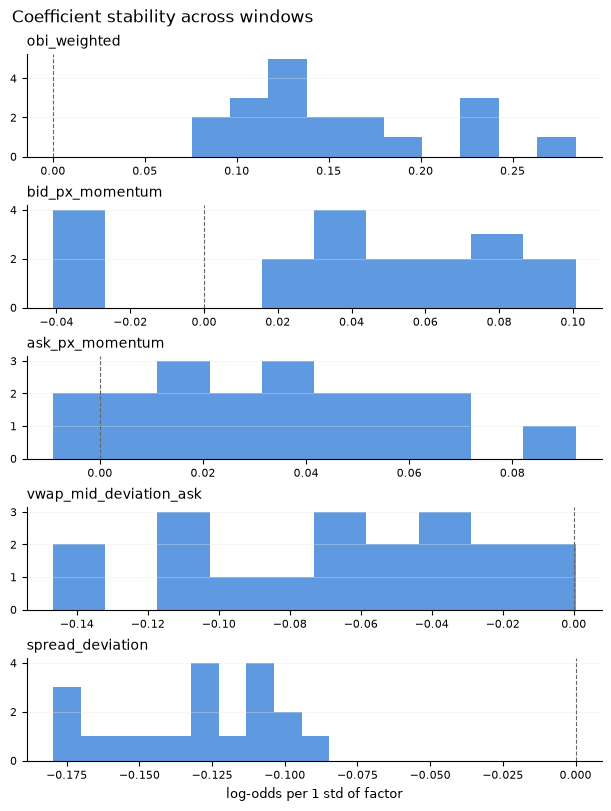

In [162]:
def backtest_and_evaluate(data,
                          data_depth=data_depth,
                          factor_hyperparameters=FACTOR_HYPERPARAMETERS_DIRECTION,
                          label_hyperparameters=LABEL_HYPERPARAMETERS,
                          train_window_size_mins=25,
                          test_window_size_mins=5,
                          step_size_mins=5,
                          purge_secs=1,
                          dir_threshold=0.56,
                          sig_resample_freq=None,
                          execution_lag_ticks=0,
                          ):
    """
    Same steps as the sections above, parameterized by `data` so the whole
    pipeline can be re-run on a different split (e.g. data_holdout) without
    duplicating the cells.
    """
    factors, labels = load_factors_and_labels(
        data=data,
        data_depth=data_depth,
        factor_hyperparameters=factor_hyperparameters,
        label_hyperparameters=label_hyperparameters,
        dropna=True)

    X = factors
    y = labels['ask_return_direction']
    rolling_window_generator = RollingWindowGenerator(X=X,
                                                      y=y,
                                                      train_window_size_mins=train_window_size_mins,
                                                      test_window_size_mins=test_window_size_mins,
                                                      step_size_mins=step_size_mins,
                                                      purge_secs=purge_secs)
    windows = list(iter(rolling_window_generator))
    print(f"Windows count: {len(windows)}")
    if windows:
        print(f"Windows start time: {windows[0].train_start}")
        print(f"Windows end time: {windows[-1].test_end}")

    dir_model = PredictionModel(
        model=LogisticRegression(l1_ratio=0, C=0.01, max_iter=10000),
        scaler=StandardScaler(),
    )
    strategy = StrategyDirection(dir_pred_model=dir_model,
                                 dir_threshold=dir_threshold,
                                 sig_resample_freq=sig_resample_freq)
    trading_simulator = TradingSimulator(raw_price=data[['ask_px_00', 'bid_px_00']],
                                         execution_lag_ticks=execution_lag_ticks)

    trading_result, model_coeff = run_simulation(strategy=strategy,
                                                 trading_simulator=trading_simulator,
                                                 windows=windows)

    stats = summarize_results(trading_result)
    display(stats)
    baseline_stats = baseline_comparison(trading_result)
    display(baseline_stats)

    plot_cumulative_pnl(trading_result['pnl'].cumsum())
    plot_price_path(trading_result)
    plot_price_and_pnl(trading_result)
    plot_execution_second_distribution(trading_result['execution_second'], bins=50)
    plot_pnl_histogram(trading_result['pnl'], bins=30)
    plot_coefficient_distribution(model_coeff, bins=10)

    return trading_result, model_coeff, stats
trading_result_holdout, model_coeff_holdout, stats_holdout = backtest_and_evaluate(data_holdout)